# Research Questions   
Does humidity have a measurable effect on electricity consumption?

Are there seasonal patterns in how humidity impacts demand?

In [58]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import data 
data = pd.read_csv("/Users/jiehni/monash/ads1002/ADS1002-project/data/processed/master_data.csv")

print(data.shape)

# drop missing values
print(data["Humidity (%)"].isna().sum())
data = data.dropna(subset=["Humidity (%)"])
print(data["Humidity (%)"].isna().sum())

(1680717, 8)
1309
0


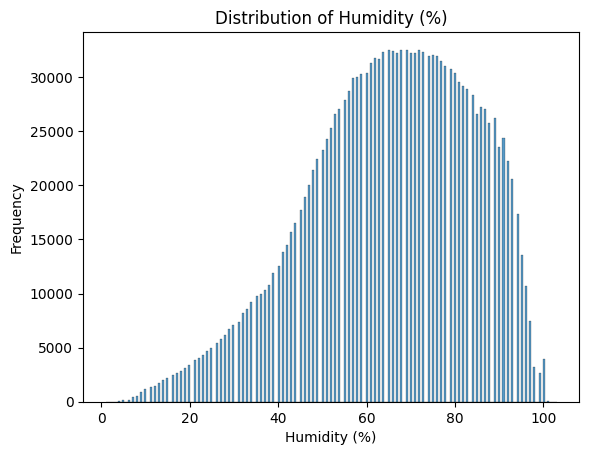

In [28]:
# plot histogram of the distribution of humidity 
sns.histplot(data["Humidity (%)"])
plt.title("Distribution of Humidity (%)")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.show()

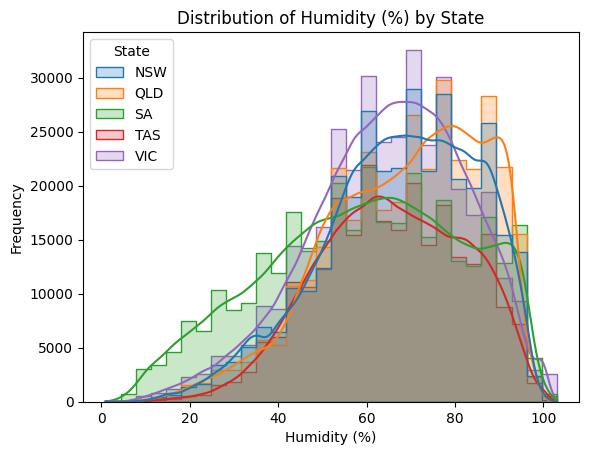

In [4]:
# plot histogram of the distribution of humidity by state
sns.histplot(data=data, x="Humidity (%)", hue="State", bins=30, kde=True, element="step")
plt.title("Distribution of Humidity (%) by State")
plt.xlabel("Humidity (%)")
plt.ylabel("Frequency")
plt.show()


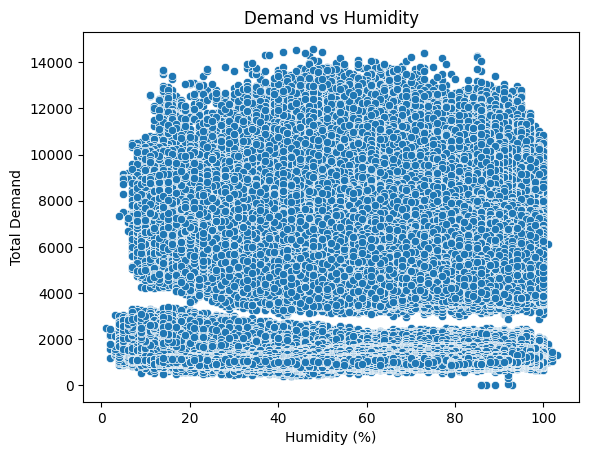

/Users/jiehni/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


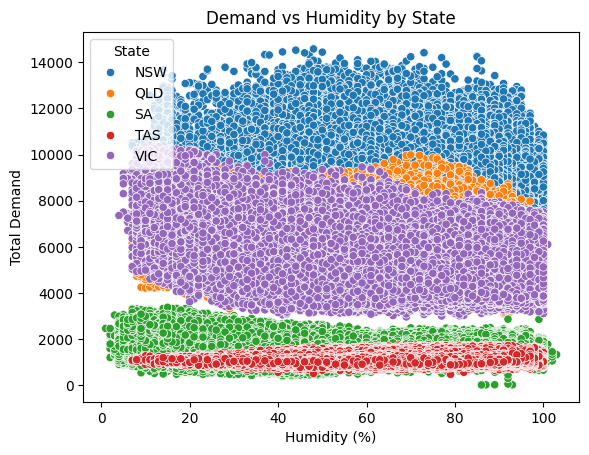

In [5]:
# plot scatterplot of humidity vs total demand
sns.scatterplot(data=data, x="Humidity (%)", y="Total Demand")
plt.title("Demand vs Humidity")
plt.show()

# plot scatterplot of humidity vs total demand by state
sns.scatterplot(data=data, x="Humidity (%)", y="Total Demand", hue="State")
plt.title("Demand vs Humidity by State")
plt.show()

/var/folders/0d/qf_dfhwn3vjd4fvry35670240000gn/T/ipykernel_93503/2187668146.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(8000, len(g)), random_state=42))


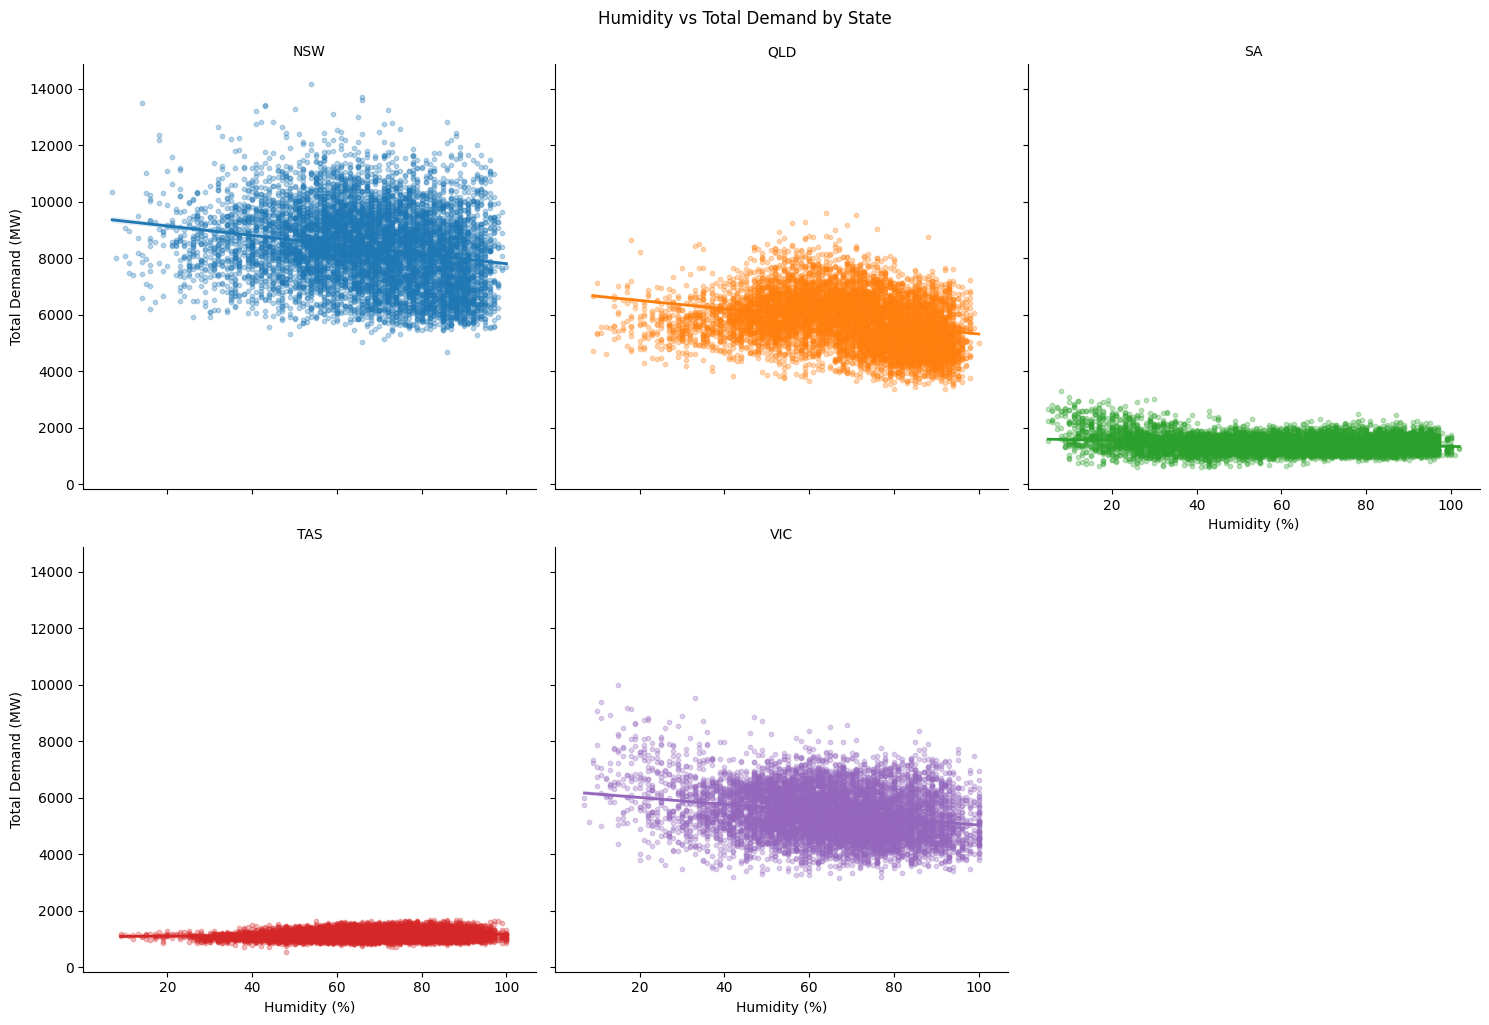

In [59]:
# downsample data, random sample up to 8000 rows per state
df_sample = (
    data.groupby("State", group_keys=False)
        .apply(lambda g: g.sample(n=min(8000, len(g)), random_state=42))
        .reset_index(drop=True)
)

# plot lmplot of humidity vs total demand (scatter plot + linear regression line) and separate into states
g = sns.lmplot(
    data=df_sample,
    x="Humidity (%)", y="Total Demand",
    hue="State",
    col="State", col_wrap=3,
    scatter_kws={"s": 10, "alpha": 0.3},
    line_kws={"lw": 2}
)
g.set_axis_labels("Humidity (%)", "Total Demand (MW)")
g.set_titles("{col_name}")
g.fig.suptitle("Humidity vs Total Demand by State", y=1.02)
plt.show()


In [60]:
# extract month
data["Month"] = pd.to_datetime(data["Datetime"]).dt.month

# convert month to season
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"
data["Season"] = data["Month"].apply(get_season)

/var/folders/0d/qf_dfhwn3vjd4fvry35670240000gn/T/ipykernel_93503/2621803699.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly = data.groupby(["Humidity Band","Hour"])["Total Demand"].mean().reset_index()


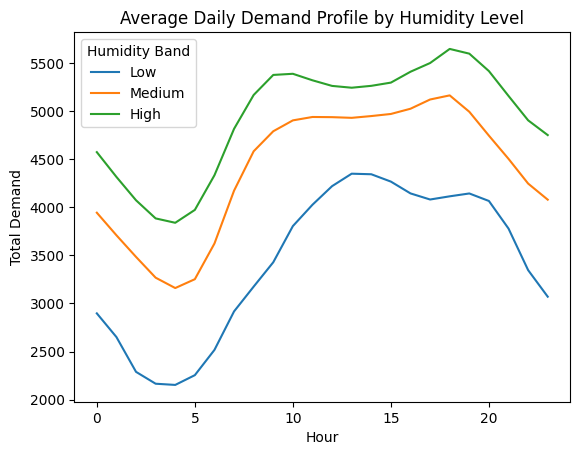

In [61]:
# group humidity into bands 0-33%, 33-67%, 67-100%
data["Humidity Band"] = pd.cut(data["Humidity (%)"], bins=[0,33,67,100], labels=["Low","Medium","High"])

# extract hour from datetime
data["Datetime"] = pd.to_datetime(data["Datetime"])
data["Hour"] = data["Datetime"].dt.hour

# create hourly data df
hourly = data.groupby(["Humidity Band","Hour"])["Total Demand"].mean().reset_index()

# plot line plot of hourly data vs demand by humidity band
sns.lineplot(data=hourly, x="Hour", y="Total Demand", hue="Humidity Band")
plt.title("Average Daily Demand Profile by Humidity Level")
plt.show()

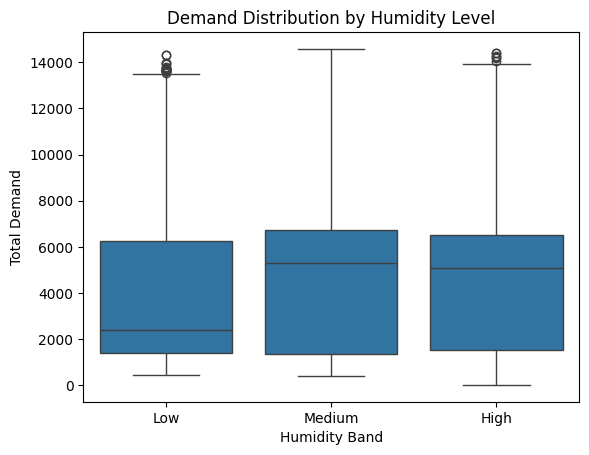

In [15]:
# plot box plot of the demand distribution by humidity band
sns.boxplot(data=data, x="Humidity Band", y="Total Demand")
plt.title("Demand Distribution by Humidity Level")
plt.show()

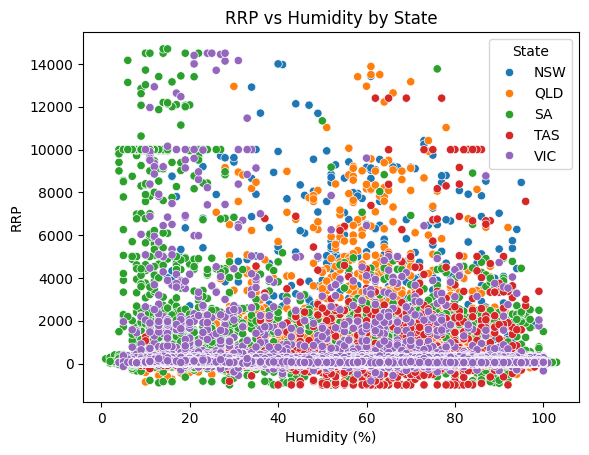

In [16]:
# plot scatter plot of humidity vs rrp by state
sns.scatterplot(data=data, x="Humidity (%)", y="RRP", hue="State")
plt.title("RRP vs Humidity by State")
plt.show()

- Does not look like there is a strong relationship between RRP and humidity
- In fact, according to the heat map, there is a negative -0.043 linear relationship between the two variables

<function matplotlib.pyplot.show(close=None, block=None)>

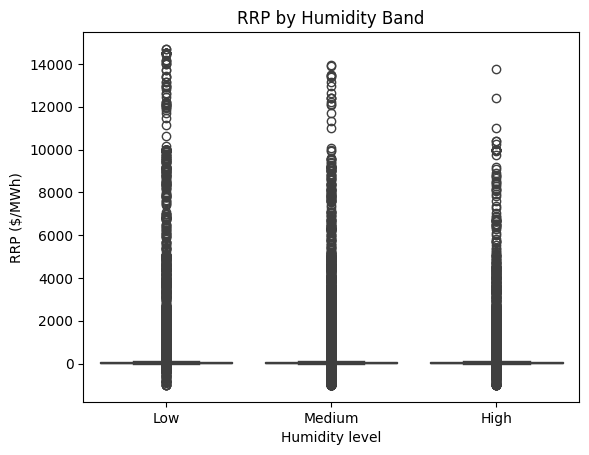

In [18]:
# plot box plot of the rrp distribution by humidity band
sns.boxplot(data=data, x="Humidity Band", y="RRP")
plt.title("RRP by Humidity Band")
plt.xlabel("Humidity level")
plt.ylabel("RRP ($/MWh)")
plt.show

In [62]:
# import statsmodels
import statsmodels.formula.api as smf

# rename columns
data = data.rename(columns={"Humidity (%)": "Humidity", "Total Demand": "Demand", "Air Temp (C)": "Temperature"})

# perform ordinary least squares regression and r^2 and for each state
for state in data['State'].unique():
    model = smf.ols("Demand ~ Humidity", data=data[data['State']==state]).fit()
    print(
        f"{state}: Intercept={model.params['Intercept']:.2f}, "
        f"Slope={model.params['Humidity']:.2f}, "
        f"R²={model.rsquared:.4f}"
    )


NSW: Intercept=9418.81, Slope=-16.19, R²=0.0426
QLD: Intercept=6787.25, Slope=-14.75, R²=0.0791
SA: Intercept=1586.00, Slope=-2.40, R²=0.0299
TAS: Intercept=1082.18, Slope=0.78, R²=0.0070
VIC: Intercept=6239.14, Slope=-11.78, R²=0.0542


Observations:

NSW (Intercept 9419, Humidity -16.2, R²=0.0426)
- Demand decreases by ~16 MW for every +1% humidity. Strongest negative slope.
- Humidity explains only 4.3% of the variability in demand.

QLD (Intercept 6787, Humidity -14.7, R²=0.0791)
- Demand decreases ~15 MW per +1% humidity. Similar pattern to NSW.
- Humidity explains ~8% of demand variation.

SA (Intercept 1586, Humidity -2.4, R²=0.0299)
- Small negative slope, ~2 MW less per +1% humidity. Effect is weaker.
- Very weak explanatory power.

TAS (Intercept 1082, Humidity +0.78, R²=0.0070)
- Tiny positive slope, demand slightly increases with humidity.
- Essentially no relationship.

VIC (Intercept 6239, Humidity -11.8, R²=0.0542)
- Demand decreases ~12 MW per +1% humidity. Negative relationship like NSW/QLD.
- Slightly stronger than NSW, but still weak.

Conclusions:

NSW, QLD, VIC: Strong negative humidity–demand relationship.
- Possibly because high humidity often coincides with cooler, cloudy, rainy weather → less air conditioning use.
- Or temperature drives demand, not humidity.

SA: Very weak negative slope.
- Humidity doesn’t seem to matter much.

TAS: Small positive slope.
- Could be noise, or local conditions.

While regression slopes show a negative relationship between humidity and demand in NSW, QLD, and VIC, the low R² values (<10%) suggest humidity alone is not a strong predictor. It likely interacts with other weather variables (temperature, seasonality) to influence demand.

In [77]:
import statsmodels.formula.api as smf

data["State"] = data["State"].astype("category")

# perform multiple ordinary least squares regression
model = smf.ols("Demand ~ Humidity + Temperature + I(Temperature**2)", data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Demand   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                 7.931e+04
Date:                Tue, 23 Sep 2025   Prob (F-statistic):               0.00
Time:                        10:11:20   Log-Likelihood:            -1.5619e+07
No. Observations:             1679408   AIC:                         3.124e+07
Df Residuals:                 1679404   BIC:                         3.124e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -2157.2057    

In [71]:
model_notemp = smf.ols(
    "Demand ~ Humidity + State", 
    data=data
).fit()

print(model_notemp.summary())

                            OLS Regression Results                            
Dep. Variable:                 Demand   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                 3.339e+06
Date:                Tue, 23 Sep 2025   Prob (F-statistic):               0.00
Time:                        10:09:03   Log-Likelihood:            -1.3721e+07
No. Observations:             1679408   AIC:                         2.744e+07
Df Residuals:                 1679402   BIC:                         2.744e+07
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     8918.9692      2.817   3166.679   

/var/folders/0d/qf_dfhwn3vjd4fvry35670240000gn/T/ipykernel_93503/2378270571.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  humidity_temp = data.groupby(["Temperature Band","Humidity"])["Demand"].mean().reset_index()


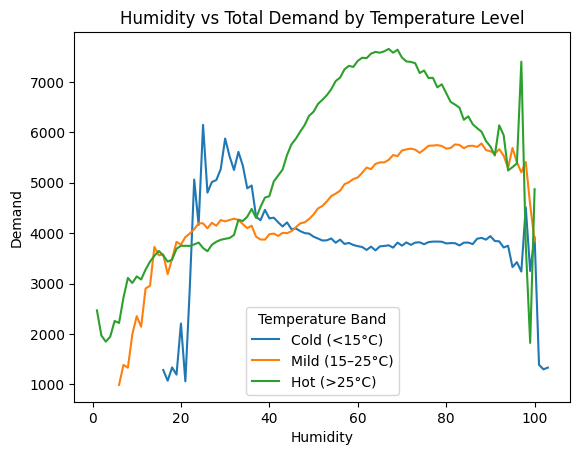

In [66]:
# create temperature bands
data["Temperature Band"] = pd.cut(data["Temperature"], bins=[-50, 15, 25, 60], labels=["Cold (<15°C)", "Mild (15–25°C)", "Hot (>25°C)"])

# create hourly data df
humidity_temp = data.groupby(["Temperature Band","Humidity"])["Demand"].mean().reset_index()

# plot line plot of hourly data vs demand by humidity band
sns.lineplot(data=humidity_temp, x="Humidity", y="Demand", hue="Temperature Band")
plt.title("Humidity vs Total Demand by Temperature Level")
plt.show()

In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd

data["Month"] = data["Datetime"].dt.month
data["Year"] = data["Datetime"].dt.year

df_ml = pd.get_dummies(data[["Demand","Humidity","Temperature","Season","State","Hour", "Month", "Year"]], drop_first=True)

# subsample to 50k rows
df_ml_sample = df_ml.sample(n=50000, random_state=42)

X = df_ml_sample.drop("Demand", axis=1)
y = df_ml_sample["Demand"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,       # cap depth
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

feat_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feat_importance.head(10))


Test R²: 0.978323368966615
State_TAS        0.448567
State_SA         0.337696
State_QLD        0.083516
Hour             0.045032
State_VIC        0.044818
Temperature      0.014406
Year             0.013834
Season_Winter    0.005440
Humidity         0.003786
Month            0.002465
dtype: float64


In [75]:
# overall model: lasso regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

data["t2"] = (data["Temperature"])**2
data["t3"] = (data["Temperature"])**3

# select features
features = ["Temperature", "t2", "t3", "Precipitation (mm)", "Humidity", "Wind Speed (km/h)", "Hour", "Month", "Year"]
target = "RRP"

# one-hot encode categoricals 
df_ml = pd.get_dummies(data[features + [target]], drop_first=True).dropna()

X = df_ml.drop(columns=[target])
y = df_ml[target]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# standardise
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# fit lasso cross validation
lasso = LassoCV(cv=5, random_state=42, n_jobs=-1)
lasso.fit(X_train_scaled, y_train)

# evaluate
y_pred = lasso.predict(X_test_scaled)
print("Best alpha (λ):", lasso.alpha_)
print("Test R²:", r2_score(y_test, y_pred))

# results
coef = pd.Series(lasso.coef_, index=X.columns)
print("\nLasso Coefficients (non-zero):")
print(coef[coef != 0].sort_values(ascending=False))

print("\nDropped variables (coeff=0):")
print(coef[coef == 0].index.tolist())


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4021599.3932418823, tolerance: 2959766.3522266285
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4186754.1616859436, tolerance: 2959766.3522266285
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4204161.999904633, tolerance: 2959766.3522266285
  model = cd_fast.enet_coo

Best alpha (λ): 0.025346638057014804
Test R²: 0.05332750908885653

Lasso Coefficients (non-zero):
t3                    353.665770
Temperature           172.294529
Year                   14.913425
Hour                    7.454492
Humidity                4.900791
Wind Speed (km/h)      -0.140591
Precipitation (mm)     -1.194018
Month                  -4.135383
t2                   -494.639766
dtype: float64

Dropped variables (coeff=0):
[]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.083e+10, tolerance: 3.788e+06
  model = cd_fast.enet_coordinate_descent(


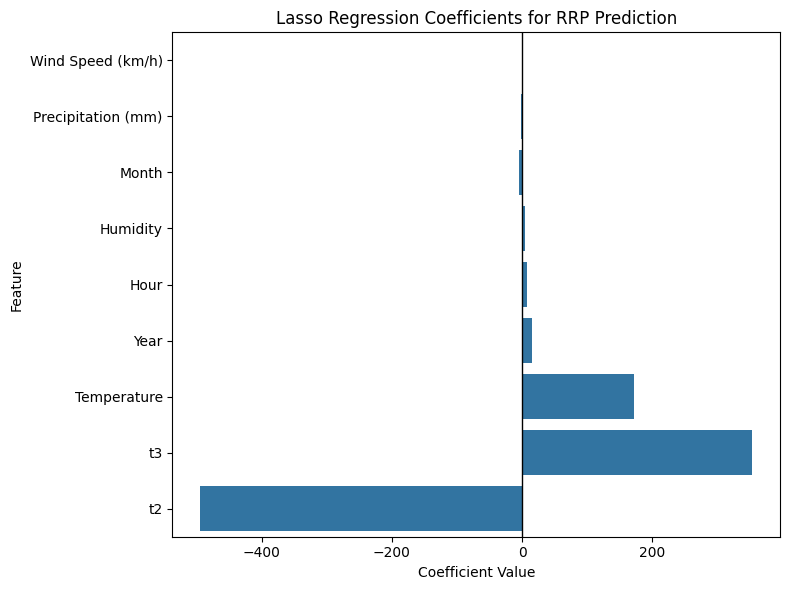

In [76]:
coef = pd.Series(lasso.coef_, index=X.columns)
coef_sorted = coef.reindex(coef.abs().sort_values(ascending=True).index)

plt.figure(figsize=(8,6))
sns.barplot(x=coef_sorted.values, y=coef_sorted.index)

plt.axvline(0, color="black", lw=1)
plt.title("Lasso Regression Coefficients for RRP Prediction")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()